# code for D.1

In [5]:
import os
import sys
import numpy as np
import torch
import pandas as pd
from pathlib import Path

torch.manual_seed(756)
np.random.seed(756)

# =========================================================
# Notebook mode
# Current notebook assumed at:
#   /MFDNN_code/AppendixD
# =========================================================
APPENDIXD_DIR = Path.cwd().resolve()
PROJECT_ROOT = APPENDIXD_DIR.parent
SIMULATION_DATA_DIR = PROJECT_ROOT / "Simulation" / "Data"
RESULTS_DIR = APPENDIXD_DIR / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

from Method.mfdnn import MFDNN, MFDNN_predict
from Method.utils import *

# =========================================================
# basic settings
# =========================================================
T = 16
n = 400


lam1_values = [0.5, 1, 1.5, 2, 2.5, 3]
lam2_values = [0, 0.001, 0.01, 0.1, 0.5, 1]

model_params = {
    "num_basis": (5, 5),
    "layer_sizes": [64, 64],
    "epochs": 100,
    "val_ratio": 0.25,
    "patience": 10,
}

ground_truth = {
    0: {0, 1},       # y1: {1,2}
    1: {1, 4, 5},    # y2: {2,5,6}
    2: {0, 2, 3, 5}, # y3: {1,3,4,6}
    3: {0, 1},       # y4: {1,2}
    4: {1, 4, 5},    # y5: {2,5,6}
    5: {0, 2, 3, 5}  # y6: {1,3,4,6}
}

epsilon = 0.01
frun = 50
# frun = 50
basis_type = "bspline"
degree = 3

# =========================================================
# load data
# =========================================================
Xlist = np.load(
    SIMULATION_DATA_DIR / f"Xlist_T{T}_n{n}.npy",
    allow_pickle=True
)
ylist = np.load(
    SIMULATION_DATA_DIR / f"ylist_T{T}_n{n}.npy",
    allow_pickle=True
)

# =========================================================
# helper functions
# =========================================================
def calculate_selection_metrics(l21_norms, true_vars, epsilon=0.01):
    selected_vars = set(i for i, norm in enumerate(l21_norms) if norm > epsilon)

    true_positive = len(selected_vars & true_vars)
    false_positive = len(selected_vars - true_vars)
    false_negative = len(true_vars - selected_vars)

    denom = 2 * true_positive + false_positive + false_negative
    f1_score = (2 * true_positive) / denom if denom > 0 else 0.0
    perfect_selection = 1.0 if selected_vars == true_vars else 0.0

    return f1_score, perfect_selection, selected_vars


def get_lambda_grids(strategy, lam1_grid, lam2_grid):
    if strategy == "joint":
        return lam1_grid, lam2_grid
    elif strategy == "lam2_zero":
        return lam1_grid, [0]
    elif strategy == "lam1_zero":
        return [0], lam2_grid
    else:
        raise ValueError(f"Unknown strategy: {strategy}")


def select_best_hyperparameters_strategy(
    X_train,
    y_train,
    true_vars,
    p,
    domain_range,
    lam1_grid,
    lam2_grid,
    model_params,
    strategy="joint",   # "joint", "lam2_zero", "lam1_zero"
    epsilon=0.01,
    basis_type="bspline",
    degree=3
):
    """
    Hyperparameter rule:
    first maximize F1, then break ties by validation MSE.
    """
    selection_info = {}

    y_train_mean = np.mean(y_train)
    y_train_std = np.std(y_train)

    lam1_use, lam2_use = get_lambda_grids(strategy, lam1_grid, lam2_grid)

    for lam1 in lam1_use:
        for lam2 in lam2_use:
            try:
                train_losses, val_losses, model, l21 = MFDNN(
                    p=p,
                    resp=y_train,
                    func_cov=X_train,
                    num_basis=model_params["num_basis"],
                    layer_sizes=model_params["layer_sizes"],
                    domain_range=domain_range,
                    epochs=model_params["epochs"],
                    val_ratio=model_params["val_ratio"],
                    patience=model_params["patience"],
                    lam1=lam1,
                    lam2=lam2,
                    std_resp=True,
                    basis_type=basis_type,
                    degree=degree
                )

                current_mse = min(val_losses) if len(val_losses) > 0 else np.mean(train_losses[-10:])

                f1_score, perfect_selection, selected_vars = calculate_selection_metrics(
                    l21, true_vars, epsilon
                )

                selection_info[(lam1, lam2)] = {
                    "model": model,
                    "lam1": lam1,
                    "lam2": lam2,
                    "f1_score": f1_score,
                    "mse": current_mse,
                    "selected_vars": list(selected_vars),
                    "y_mean": y_train_mean,
                    "y_std": y_train_std,
                    "perfect_selection": perfect_selection
                }

            except Exception:
                continue

    if len(selection_info) == 0:
        return None

    best_key = max(
        selection_info.keys(),
        key=lambda key: (selection_info[key]["f1_score"], -selection_info[key]["mse"])
    )
    return selection_info[best_key]


def evaluate_on_test_set(best_candidate, X_test, y_test, p, domain_range, model_params,
                         basis_type="bspline", degree=3):
    if best_candidate is None or best_candidate["model"] is None:
        return np.inf, 0.0, []

    try:
        y_mean = best_candidate["y_mean"]
        y_std = best_candidate["y_std"]

        test_predictions_normalized = MFDNN_predict(
            p,
            best_candidate["model"],
            X_test,
            model_params["num_basis"],
            domain_range,
            basis_type=basis_type,
            degree=degree
        )
        test_predictions_original = test_predictions_normalized.detach().numpy() * y_std + y_mean

        test_mse = np.mean((test_predictions_original.flatten() - y_test) ** 2)
        test_rmse = np.sqrt(test_mse)
        test_nrmse = test_rmse / np.std(y_test) if np.std(y_test) > 0 else np.inf

        return test_nrmse, best_candidate["f1_score"], best_candidate["selected_vars"]
    except Exception:
        return np.inf, 0.0, []


def summarize_method_results(result_dict, frun):
    rows = []
    for y_index in range(6):
        y_key = f"y{y_index+1}"
        nrmse_arr = np.array(result_dict[y_key]["test_nrmse"], dtype=float)
        f1_arr = np.array(result_dict[y_key]["test_f1"], dtype=float)

        row = {
            "response": y_key,
            "NRMSE_Mean": np.mean(nrmse_arr),
            "NRMSE_Std": np.std(nrmse_arr),
            "F1_Mean": np.mean(f1_arr),
            "F1_Std": np.std(f1_arr),
            "PerfectMatch_Count": int(sum(result_dict[y_key]["perfect_match"])),
            "PerfectMatch_Rate": float(np.mean(result_dict[y_key]["perfect_match"]))
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    return df


def format_mean_sd(mean_val, sd_val):
    return f"{mean_val:.3f} ({sd_val:.3f})"


# =========================================================
# main comparison
# =========================================================
print(f"\n{'='*60}")
print(f"Processing T={T}, n={n}, basis={basis_type}, frun={frun}")
print(f"{'='*60}")

results_joint = {
    f"y{i+1}": {"test_nrmse": [], "test_f1": [], "perfect_match": []}
    for i in range(6)
}
results_lam2_zero = {
    f"y{i+1}": {"test_nrmse": [], "test_f1": [], "perfect_match": []}
    for i in range(6)
}
results_lam1_zero = {
    f"y{i+1}": {"test_nrmse": [], "test_f1": [], "perfect_match": []}
    for i in range(6)
}

for run_idx in range(frun):
    if (run_idx + 1) % 2 == 0 or run_idx == 0:
        print(f"  Run {run_idx+1}/{frun}")

    X = np.array(Xlist[run_idx])
    p, N, T1, T2 = X.shape

    split_idx = N // 2
    X_train = X[:, :split_idx, :, :]
    X_test = X[:, split_idx:, :, :]

    domain_range = [[[0, 0], [1, 1]] for _ in range(p)]

    for y_index in range(6):
        y_key = f"y{y_index+1}"
        y_full = np.array(ylist[run_idx][y_index])
        y_train = y_full[:split_idx]
        y_test = y_full[split_idx:]

        true_vars = ground_truth[y_index]

        # 1) joint tuning
        best_joint = select_best_hyperparameters_strategy(
            X_train, y_train, true_vars, p, domain_range,
            lam1_values, lam2_values, model_params,
            strategy="joint",
            epsilon=epsilon,
            basis_type=basis_type,
            degree=degree
        )
        joint_nrmse, joint_f1, joint_selected = evaluate_on_test_set(
            best_joint, X_test, y_test, p, domain_range, model_params,
            basis_type=basis_type,
            degree=degree
        )
        joint_perfect = 1 if set(joint_selected) == true_vars else 0

        results_joint[y_key]["test_nrmse"].append(joint_nrmse)
        results_joint[y_key]["test_f1"].append(joint_f1)
        results_joint[y_key]["perfect_match"].append(joint_perfect)

        # 2) lam2 = 0, tune lam1 only
        best_lam2_zero = select_best_hyperparameters_strategy(
            X_train, y_train, true_vars, p, domain_range,
            lam1_values, lam2_values, model_params,
            strategy="lam2_zero",
            epsilon=epsilon,
            basis_type=basis_type,
            degree=degree
        )
        lam2_zero_nrmse, lam2_zero_f1, lam2_zero_selected = evaluate_on_test_set(
            best_lam2_zero, X_test, y_test, p, domain_range, model_params,
            basis_type=basis_type,
            degree=degree
        )
        lam2_zero_perfect = 1 if set(lam2_zero_selected) == true_vars else 0

        results_lam2_zero[y_key]["test_nrmse"].append(lam2_zero_nrmse)
        results_lam2_zero[y_key]["test_f1"].append(lam2_zero_f1)
        results_lam2_zero[y_key]["perfect_match"].append(lam2_zero_perfect)

        # 3) lam1 = 0, tune lam2 only
        best_lam1_zero = select_best_hyperparameters_strategy(
            X_train, y_train, true_vars, p, domain_range,
            lam1_values, lam2_values, model_params,
            strategy="lam1_zero",
            epsilon=epsilon,
            basis_type=basis_type,
            degree=degree
        )
        lam1_zero_nrmse, lam1_zero_f1, lam1_zero_selected = evaluate_on_test_set(
            best_lam1_zero, X_test, y_test, p, domain_range, model_params,
            basis_type=basis_type,
            degree=degree
        )
        lam1_zero_perfect = 1 if set(lam1_zero_selected) == true_vars else 0

        results_lam1_zero[y_key]["test_nrmse"].append(lam1_zero_nrmse)
        results_lam1_zero[y_key]["test_f1"].append(lam1_zero_f1)
        results_lam1_zero[y_key]["perfect_match"].append(lam1_zero_perfect)

# summarize
df_joint = summarize_method_results(results_joint, frun)
df_lam2_zero = summarize_method_results(results_lam2_zero, frun)
df_lam1_zero = summarize_method_results(results_lam1_zero, frun)

merged = pd.DataFrame({
    "response": df_joint["response"],
    "Joint tuning": [
        format_mean_sd(m, s) for m, s in zip(df_joint["NRMSE_Mean"], df_joint["NRMSE_Std"])
    ],
    "λ2=0": [
        format_mean_sd(m, s) for m, s in zip(df_lam2_zero["NRMSE_Mean"], df_lam2_zero["NRMSE_Std"])
    ],
    "λ1=0": [
        format_mean_sd(m, s) for m, s in zip(df_lam1_zero["NRMSE_Mean"], df_lam1_zero["NRMSE_Std"])
    ],
    "Joint Perfect": df_joint["PerfectMatch_Count"].astype(str) + f"/{frun}",
    "λ2=0 Perfect": df_lam2_zero["PerfectMatch_Count"].astype(str) + f"/{frun}",
    "λ1=0 Perfect": df_lam1_zero["PerfectMatch_Count"].astype(str) + f"/{frun}",
})

print(f"\n===== Comparison table for T={T}, n={n}, bspline =====")
print(merged)

save_path = RESULTS_DIR / f"penalty_compare_T{T}_n{n}.csv"
merged.to_csv(save_path, index=False)
print(f"Saved to: {save_path}")


Processing T=16, n=400, basis=bspline, frun=50
  Run 1/50
  Run 2/50
  Run 4/50
  Run 6/50
  Run 8/50
  Run 10/50
  Run 12/50
  Run 14/50
  Run 16/50
  Run 18/50
  Run 20/50
  Run 22/50
  Run 24/50
  Run 26/50
  Run 28/50
  Run 30/50
  Run 32/50
  Run 34/50
  Run 36/50
  Run 38/50
  Run 40/50
  Run 42/50
  Run 44/50
  Run 46/50
  Run 48/50
  Run 50/50

===== Comparison table for T=16, n=400, bspline =====
  response   Joint tuning           λ2=0           λ1=0 Joint Perfect  \
0       y1  0.329 (0.020)  0.332 (0.020)  0.378 (0.020)         50/50   
1       y2  0.336 (0.019)  0.344 (0.022)  0.378 (0.020)         50/50   
2       y3  0.342 (0.018)  0.347 (0.021)  0.378 (0.022)         48/50   
3       y4  0.347 (0.017)  0.354 (0.019)  0.378 (0.019)         50/50   
4       y5  0.346 (0.017)  0.355 (0.021)  0.384 (0.018)         50/50   
5       y6  0.348 (0.019)  0.356 (0.019)  0.381 (0.020)         47/50   

  λ2=0 Perfect λ1=0 Perfect  
0        50/50         0/50  
1        49/50    

# code for D.2

## the number of basis functions, M1=M2=M


Run 1/50 | case6

Run 5/50 | case6

Run 10/50 | case6

Run 15/50 | case6

Run 20/50 | case6

Run 25/50 | case6

Run 30/50 | case6

Run 35/50 | case6

Run 40/50 | case6

Run 45/50 | case6

Run 50/50 | case6

===== Joint tuning (λ1, λ2) =====
    case   T    N  M  NRMSE_Mean  NRMSE_Std   F1_Mean        F1_Std  \
0  case6  16  400  4    0.346895   0.021591  0.800000  2.220446e-16   
1  case6  16  400  5    0.346715   0.017167  0.986286  4.720429e-02   
2  case6  16  400  6    0.349733   0.017114  1.000000  0.000000e+00   
3  case6  16  400  7    0.356520   0.016045  1.000000  0.000000e+00   
4  case6  16  400  8    0.365662   0.016295  1.000000  0.000000e+00   

   PerfectMatch_Count  PerfectMatch_Rate  ...  X2_Count  X2_Freq  X3_Count  \
0                   0               0.00  ...        50     1.00        50   
1                  46               0.92  ...         2     0.04        50   
2                  50               1.00  ...         0     0.00        50   
3                  

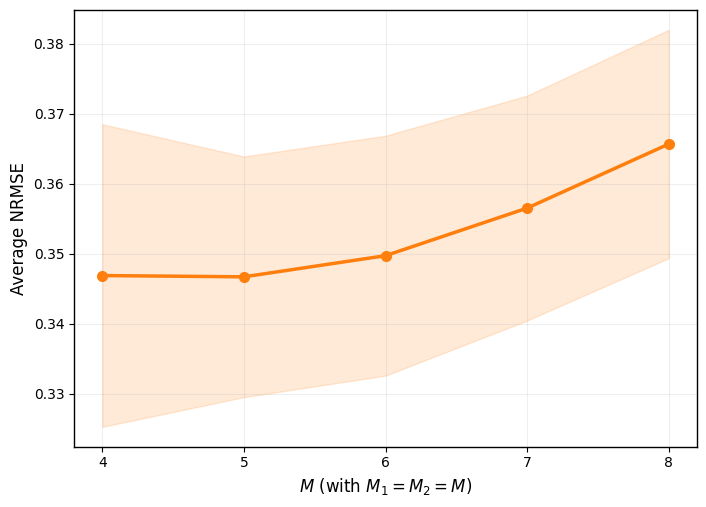


Saved summary to:
/Users/wangdongxue/Desktop/MFDNN_STCO_revise/MFDNN_code/AppendixD/Results/sensitivity_M_summary_T16_n400.csv
Saved figure to:
/Users/wangdongxue/Desktop/MFDNN_STCO_revise/MFDNN_code/AppendixD/Results/sensitivity_M.jpeg

Saved summary to:
/Users/wangdongxue/Desktop/MFDNN_STCO_revise/MFDNN_code/AppendixD/Results/sensitivity_M_summary_T16_n400.csv
Saved figure to:
/Users/wangdongxue/Desktop/MFDNN_STCO_revise/MFDNN_code/AppendixD/Results/sensitivity_M.jpeg


In [6]:
import os
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(756)
np.random.seed(756)

# =========================================================
# Notebook mode
# Current notebook assumed at:
#   /MFDNN_code/AppendixD
# =========================================================
APPENDIXD_DIR = Path.cwd().resolve()
PROJECT_ROOT = APPENDIXD_DIR.parent
SIMULATION_DATA_DIR = PROJECT_ROOT / "Simulation" / "Data"
RESULTS_DIR = APPENDIXD_DIR / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

from Method.mfdnn import MFDNN, MFDNN_predict
from Method.utils import *

# =========================================================
# basic settings
# =========================================================
T = 16
n = 400
#frun = 50
frun = 50
epsilon = 0.01

basis_type = "bspline"
degree = 3

case_index = 5
case_name = f"case{case_index + 1}"

ground_truth = {
    0: {0, 1},
    1: {1, 4, 5},
    2: {0, 2, 3, 5},
    3: {0, 1},
    4: {1, 4, 5},
    5: {0, 2, 3, 5}
}
true_vars = ground_truth[case_index]

M_values = [4, 5, 6, 7, 8]

lam1_values = [0.5, 1, 1.5, 2, 2.5, 3]
lam2_values = [0, 0.001, 0.01, 0.1, 0.5, 1]

fixed_layer_sizes = [64, 64]
fixed_epochs = 100
fixed_val_ratio = 0.25
fixed_patience = 10

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# =========================================================
# load data
# =========================================================
Xlist = np.load(
    SIMULATION_DATA_DIR / f"Xlist_T{T}_n{n}.npy",
    allow_pickle=True
)
ylist = np.load(
    SIMULATION_DATA_DIR / f"ylist_T{T}_n{n}.npy",
    allow_pickle=True
)

# =========================================================
# helpers
# =========================================================
def calculate_selection_metrics(l21_norms, true_vars, epsilon=0.01):
    selected_vars = set(i for i, norm in enumerate(l21_norms) if norm > epsilon)

    true_positive = len(selected_vars & true_vars)
    false_positive = len(selected_vars - true_vars)
    false_negative = len(true_vars - selected_vars)

    denom = 2 * true_positive + false_positive + false_negative
    f1_score = (2 * true_positive) / denom if denom > 0 else 0.0
    perfect_selection = 1.0 if selected_vars == true_vars else 0.0

    return f1_score, perfect_selection, selected_vars


def init_result_container(M_values):
    return {
        M: {
            "nrmse": [],
            "f1": [],
            "perfect_match": [],
            "selection_counts": np.zeros(6, dtype=int),
        }
        for M in M_values
    }


def summarize_results(result_dict, M_values, frun, case_name, T, n):
    rows = []
    for M in M_values:
        res = result_dict[M]
        nrmse_arr = np.array(res["nrmse"], dtype=float)
        f1_arr = np.array(res["f1"], dtype=float)

        row = {
            "case": case_name,
            "T": T,
            "N": n,
            "M": M,
            "NRMSE_Mean": np.mean(nrmse_arr),
            "NRMSE_Std": np.std(nrmse_arr),
            "F1_Mean": np.mean(f1_arr),
            "F1_Std": np.std(f1_arr),
            "PerfectMatch_Count": int(np.sum(res["perfect_match"])),
            "PerfectMatch_Rate": float(np.mean(res["perfect_match"]))
        }

        for j in range(6):
            row[f"X{j+1}_Count"] = int(res["selection_counts"][j])
            row[f"X{j+1}_Freq"] = res["selection_counts"][j] / frun

        rows.append(row)

    return pd.DataFrame(rows).sort_values(by="M").reset_index(drop=True)


def select_best_hyperparameters_strategy(
    X_train,
    y_train,
    true_vars,
    p,
    domain_range,
    lam1_grid,
    lam2_grid,
    model_params,
    strategy="joint",
    epsilon=0.01,
    basis_type="bspline",
    degree=3
):
    selection_info = {}

    y_train_mean = np.mean(y_train)
    y_train_std = np.std(y_train)

    for i, lam1 in enumerate(lam1_grid):
        for j, lam2 in enumerate(lam2_grid):

            if strategy == "lam2_zero" and lam2 != 0:
                continue

            try:
                train_losses, val_losses, model, l21 = MFDNN(
                    p=p,
                    resp=y_train,
                    func_cov=X_train,
                    num_basis=model_params['num_basis'],
                    layer_sizes=model_params['layer_sizes'],
                    domain_range=domain_range,
                    epochs=model_params['epochs'],
                    val_ratio=model_params['val_ratio'],
                    patience=model_params['patience'],
                    lam1=lam1,
                    lam2=lam2,
                    std_resp=True,
                    basis_type=basis_type,
                    degree=degree
                )

                current_mse = min(val_losses) if len(val_losses) > 0 else np.mean(train_losses[-10:])

                f1_score, perfect_selection, selected_vars = calculate_selection_metrics(
                    l21, true_vars, epsilon
                )

                selection_info[(i, j)] = {
                    'model': model,
                    'lam1': lam1,
                    'lam2': lam2,
                    'f1_score': f1_score,
                    'mse': current_mse,
                    'selected_vars': list(selected_vars),
                    'y_mean': y_train_mean,
                    'y_std': y_train_std,
                    'perfect_selection': perfect_selection
                }

            except Exception:
                continue

    valid_keys = list(selection_info.keys())
    if len(valid_keys) == 0:
        return None

    best_key = max(
        valid_keys,
        key=lambda key: (selection_info[key]['f1_score'], -selection_info[key]['mse'])
    )
    return selection_info[best_key]


def evaluate_on_test_set(best_candidate, X_test, y_test, p, domain_range, model_params,
                         basis_type="bspline", degree=3):
    if best_candidate is None or best_candidate['model'] is None:
        return np.inf, 0.0, []

    try:
        y_mean = best_candidate['y_mean']
        y_std = best_candidate['y_std']

        test_predictions_normalized = MFDNN_predict(
            p,
            best_candidate['model'],
            X_test,
            model_params['num_basis'],
            domain_range,
            basis_type=basis_type,
            degree=degree
        )
        test_predictions_original = test_predictions_normalized.detach().numpy() * y_std + y_mean

        test_mse = np.mean((test_predictions_original.flatten() - y_test) ** 2)
        test_rmse = np.sqrt(test_mse)
        test_nrmse = test_rmse / np.std(y_test) if np.std(y_test) > 0 else np.inf

        return test_nrmse, best_candidate['f1_score'], best_candidate['selected_vars']
    except Exception:
        return np.inf, 0.0, []


# =========================================================
# result containers
# =========================================================
M_results_joint = init_result_container(M_values)

# =========================================================
# main loop
# =========================================================
for run_idx in range(frun):
    if (run_idx + 1) % 5 == 0 or run_idx == 0:
        print(f"\nRun {run_idx+1}/{frun} | {case_name}")

    X = np.array(Xlist[run_idx])
    p, N, T1, T2 = X.shape

    split_idx = N // 2
    X_train = X[:, :split_idx, :, :]
    X_test = X[:, split_idx:, :, :]

    domain_range = [[[0, 0], [1, 1]] for _ in range(p)]

    y_full = np.array(ylist[run_idx][case_index])
    y_train = y_full[:split_idx]
    y_test = y_full[split_idx:]

    for M in M_values:
        model_params_M = {
            'num_basis': (M, M),
            'layer_sizes': fixed_layer_sizes,
            'epochs': fixed_epochs,
            'val_ratio': fixed_val_ratio,
            'patience': fixed_patience
        }

        best_joint = select_best_hyperparameters_strategy(
            X_train, y_train, true_vars, p, domain_range,
            lam1_values, lam2_values, model_params_M,
            strategy="joint",
            epsilon=epsilon,
            basis_type=basis_type,
            degree=degree
        )
        joint_nrmse, joint_f1, joint_selected = evaluate_on_test_set(
            best_joint, X_test, y_test, p, domain_range, model_params_M,
            basis_type=basis_type,
            degree=degree
        )
        joint_perfect = 1 if set(joint_selected) == true_vars else 0

        M_results_joint[M]["nrmse"].append(joint_nrmse)
        M_results_joint[M]["f1"].append(joint_f1)
        M_results_joint[M]["perfect_match"].append(joint_perfect)
        for var_idx in joint_selected:
            M_results_joint[M]["selection_counts"][var_idx] += 1

# =========================================================
# summary
# =========================================================
summary_M_joint_df = summarize_results(M_results_joint, M_values, frun, case_name, T, n)

print("\n===== Joint tuning (λ1, λ2) =====")
print(summary_M_joint_df)

summary_csv_path = RESULTS_DIR / f"sensitivity_M_summary_T{T}_n{n}.csv"
summary_M_joint_df.to_csv(summary_csv_path, index=False)

# =========================================================
# plot: jointly tuned only
# =========================================================
orange = "#ff7f0e"

x_joint = summary_M_joint_df["M"].values
y_joint = summary_M_joint_df["NRMSE_Mean"].values
e_joint = summary_M_joint_df["NRMSE_Std"].values

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.plot(
    x_joint, y_joint, "o-", linewidth=2.5, markersize=7, color=orange
)
ax.fill_between(
    x_joint, y_joint - e_joint, y_joint + e_joint,
    alpha=0.16, color=orange
)

ax.set_xticks(M_values)
ax.set_xlabel(r"$M$ (with $M_1=M_2=M$)")
ax.set_ylabel("Average NRMSE")
ax.grid(alpha=0.2, linewidth=0.8)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()

jpeg_path = RESULTS_DIR / "sensitivity_M.jpeg"
fig.savefig(jpeg_path, dpi=300, bbox_inches="tight", format="jpeg")
plt.show()

print(f"\nSaved summary to:\n{summary_csv_path}")
print(f"Saved figure to:\n{jpeg_path}")
print(f"\nSaved summary to:\n{summary_csv_path}")
print(f"Saved figure to:\n{jpeg_path}")

## depth and width


========== Run 1/50 | case6 ==========

========== Run 5/50 | case6 ==========

========== Run 10/50 | case6 ==========

========== Run 15/50 | case6 ==========

========== Run 20/50 | case6 ==========

========== Run 25/50 | case6 ==========

========== Run 30/50 | case6 ==========

========== Run 35/50 | case6 ==========

========== Run 40/50 | case6 ==========

========== Run 45/50 | case6 ==========

========== Run 50/50 | case6 ==========

===== Depth sensitivity =====
    case   T    N  L  NRMSE_Mean  NRMSE_Std
0  case6  16  400  1    0.401819   0.047056
1  case6  16  400  2    0.347992   0.016103
2  case6  16  400  3    0.348584   0.021457
3  case6  16  400  4    0.365424   0.031916
4  case6  16  400  5    0.370685   0.030353

===== Width sensitivity =====
    case   T    N  width  NRMSE_Mean  NRMSE_Std
0  case6  16  400     16    0.469234   0.047961
1  case6  16  400     32    0.398804   0.020273
2  case6  16  400     64    0.349544   0.018029
3  case6  16  400    128    0.353

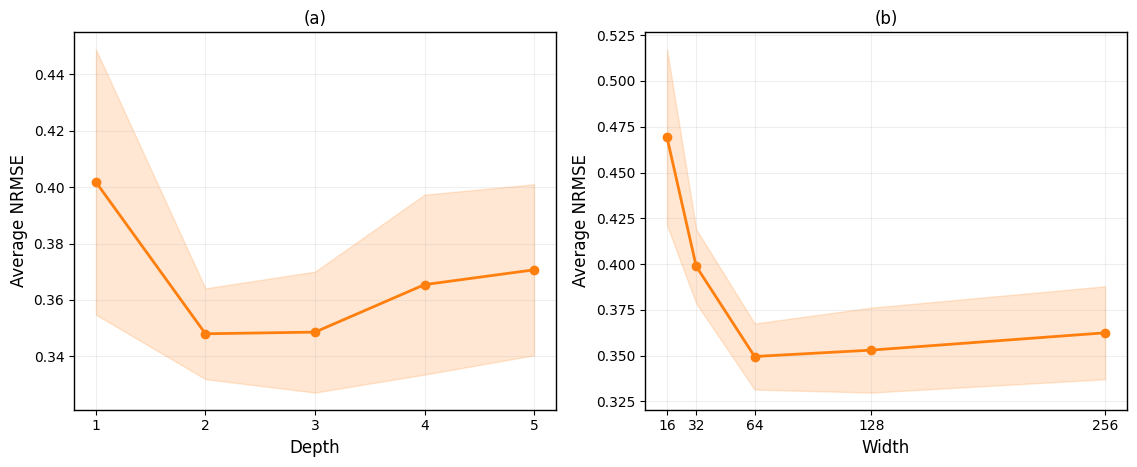

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

torch.manual_seed(756)
np.random.seed(756)

# ============================================
# Notebook mode
# Current notebook assumed at:
#   /MFDNN_code/AppendixD
# ============================================
APPENDIXD_DIR = Path.cwd().resolve()
PROJECT_ROOT = APPENDIXD_DIR.parent
SIMULATION_DATA_DIR = PROJECT_ROOT / "Simulation" / "Data"
RESULTS_DIR = APPENDIXD_DIR / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

from Method.mfdnn import MFDNN, MFDNN_predict
from Method.utils import *

# ============================================
# Sensitivity analysis for depth and width
# Case 6, T=16, N=400
# Jointly tune (lam1, lam2)
# Basis: bspline
# Plot: 1 x 2
# ============================================

# ---------- basic setting ----------
case_index = 5
case_name = "case6"

T = 16
n = 400
# frun = 50
frun = 50


L_values = [1, 2, 3, 4, 5]
width_values = [16, 32, 64, 128, 256]

fixed_M = 5
fixed_epochs = 100
fixed_val_ratio = 0.25
fixed_patience = 10

lam1_values = [0.5, 1, 1.5, 2, 2.5, 3]
lam2_values = [0, 0.001, 0.01, 0.1, 0.5, 1]

basis_type = "bspline"
degree = 3
epsilon = 0.01

ground_truth = {
    0: {0, 1},       # y1: {1,2}
    1: {1, 4, 5},    # y2: {2,5,6}
    2: {0, 2, 3, 5}, # y3: {1,3,4,6}
    3: {0, 1},       # y4: {1,2}
    4: {1, 4, 5},    # y5: {2,5,6}
    5: {0, 2, 3, 5}  # y6: {1,3,4,6}
}
true_vars = ground_truth[case_index]

# ---------- load data ----------
Xlist = np.load(
    SIMULATION_DATA_DIR / f"Xlist_T{T}_n{n}.npy",
    allow_pickle=True
)
ylist = np.load(
    SIMULATION_DATA_DIR / f"ylist_T{T}_n{n}.npy",
    allow_pickle=True
)

# ---------- helper ----------
def init_result_container(values):
    return {
        v: {
            "nrmse": []
        }
        for v in values
    }


def summarize_nrmse_results(result_dict, values, case_name, T, n, value_name):
    rows = []
    for v in values:
        arr = np.array(result_dict[v]["nrmse"], dtype=float)
        arr_ok = arr[np.isfinite(arr)]

        row = {
            "case": case_name,
            "T": T,
            "N": n,
            value_name: v,
            "NRMSE_Mean": np.mean(arr_ok) if len(arr_ok) else np.inf,
            "NRMSE_Std": np.std(arr_ok) if len(arr_ok) else np.nan,
        }
        rows.append(row)

    df = pd.DataFrame(rows).sort_values(by=value_name).reset_index(drop=True)
    return df


def calculate_selection_metrics(l21_norms, true_vars, epsilon=0.01):
    selected_vars = set(i for i, norm in enumerate(l21_norms) if norm > epsilon)

    true_positive = len(selected_vars & true_vars)
    false_positive = len(selected_vars - true_vars)
    false_negative = len(true_vars - selected_vars)

    denom = 2 * true_positive + false_positive + false_negative
    f1_score = (2 * true_positive) / denom if denom > 0 else 0.0
    perfect_selection = 1.0 if selected_vars == true_vars else 0.0

    return f1_score, perfect_selection, selected_vars


def select_best_joint_model(
    X_train,
    y_train,
    true_vars,
    p,
    domain_range,
    num_basis,
    layer_sizes,
    epochs,
    val_ratio,
    patience,
    lam1_values,
    lam2_values,
    epsilon=0.01,
    basis_type="bspline",
    degree=3
):
    """
    Joint tuning:
    first maximize F1, then break ties by validation MSE.
    """
    selection_info = {}

    y_train_mean = np.mean(y_train)
    y_train_std = np.std(y_train)

    for i, lam1 in enumerate(lam1_values):
        for j, lam2 in enumerate(lam2_values):
            try:
                train_losses, val_losses, model, l21 = MFDNN(
                    p=p,
                    resp=y_train,
                    func_cov=X_train,
                    num_basis=num_basis,
                    layer_sizes=layer_sizes,
                    domain_range=domain_range,
                    epochs=epochs,
                    val_ratio=val_ratio,
                    patience=patience,
                    lam1=lam1,
                    lam2=lam2,
                    std_resp=True,
                    basis_type=basis_type,
                    degree=degree
                )

                current_mse = min(val_losses) if len(val_losses) > 0 else np.mean(train_losses[-10:])
                f1_score, perfect_selection, selected_vars = calculate_selection_metrics(
                    l21, true_vars, epsilon
                )

                selection_info[(i, j)] = {
                    "model": model,
                    "lam1": lam1,
                    "lam2": lam2,
                    "f1_score": f1_score,
                    "mse": current_mse,
                    "selected_vars": list(selected_vars),
                    "y_mean": y_train_mean,
                    "y_std": y_train_std,
                    "perfect_selection": perfect_selection
                }

            except Exception:
                continue

    valid_keys = list(selection_info.keys())
    if len(valid_keys) == 0:
        return None

    best_key = max(
        valid_keys,
        key=lambda key: (selection_info[key]["f1_score"], -selection_info[key]["mse"])
    )
    return selection_info[best_key]


def evaluate_on_test_set(best_candidate, X_test, y_test, p, domain_range, num_basis,
                         basis_type="bspline", degree=3):
    if best_candidate is None or best_candidate["model"] is None:
        return np.inf

    try:
        y_mean = best_candidate["y_mean"]
        y_std = best_candidate["y_std"]

        yhat_std = MFDNN_predict(
            p,
            best_candidate["model"],
            X_test,
            num_basis,
            domain_range,
            basis_type=basis_type,
            degree=degree
        )
        yhat = yhat_std.detach().numpy().flatten() * y_std + y_mean

        rmse = np.sqrt(np.mean((yhat - y_test) ** 2))
        nrmse = rmse / np.std(y_test) if np.std(y_test) > 0 else np.inf
        return nrmse
    except Exception:
        return np.inf


# ---------- result containers ----------
depth_results = init_result_container(L_values)
width_results = init_result_container(width_values)

# ============================================
# Main loop
# ============================================
for run_idx in range(frun):
    if (run_idx + 1) % 5 == 0 or run_idx == 0:
        print(f"\n========== Run {run_idx+1}/{frun} | {case_name} ==========")

    X = np.array(Xlist[run_idx])   # (p, N, T1, T2)
    p, N, T1, T2 = X.shape

    split_idx = N // 2
    X_train = X[:, :split_idx, :, :]
    X_test  = X[:, split_idx:, :, :]

    domain_range = [[[0, 0], [1, 1]] for _ in range(p)]

    y_full = np.array(ylist[run_idx][case_index])
    y_train = y_full[:split_idx]
    y_test  = y_full[split_idx:]

    # ----------------------------------------
    # 1) Depth sensitivity
    # ----------------------------------------
    for L in L_values:
        layer_sizes = [64] * L

        try:
            best_candidate = select_best_joint_model(
                X_train=X_train,
                y_train=y_train,
                true_vars=true_vars,
                p=p,
                domain_range=domain_range,
                num_basis=[fixed_M, fixed_M],
                layer_sizes=layer_sizes,
                epochs=fixed_epochs,
                val_ratio=fixed_val_ratio,
                patience=fixed_patience,
                lam1_values=lam1_values,
                lam2_values=lam2_values,
                epsilon=epsilon,
                basis_type=basis_type,
                degree=degree
            )

            if best_candidate is None:
                raise RuntimeError(f"No valid model found for L={L}.")

            nrmse = evaluate_on_test_set(
                best_candidate=best_candidate,
                X_test=X_test,
                y_test=y_test,
                p=p,
                domain_range=domain_range,
                num_basis=[fixed_M, fixed_M],
                basis_type=basis_type,
                degree=degree
            )
            depth_results[L]["nrmse"].append(nrmse)

        except Exception as e:
            print(f"Run {run_idx+1}, depth L={L} failed: {e}")
            depth_results[L]["nrmse"].append(np.inf)

    # ----------------------------------------
    # 2) Width sensitivity
    # ----------------------------------------
    for width in width_values:
        layer_sizes = [width, width]   # fixed depth = 2

        try:
            best_candidate = select_best_joint_model(
                X_train=X_train,
                y_train=y_train,
                true_vars=true_vars,
                p=p,
                domain_range=domain_range,
                num_basis=[fixed_M, fixed_M],
                layer_sizes=layer_sizes,
                epochs=fixed_epochs,
                val_ratio=fixed_val_ratio,
                patience=fixed_patience,
                lam1_values=lam1_values,
                lam2_values=lam2_values,
                epsilon=epsilon,
                basis_type=basis_type,
                degree=degree
            )

            if best_candidate is None:
                raise RuntimeError(f"No valid model found for width={width}.")

            nrmse = evaluate_on_test_set(
                best_candidate=best_candidate,
                X_test=X_test,
                y_test=y_test,
                p=p,
                domain_range=domain_range,
                num_basis=[fixed_M, fixed_M],
                basis_type=basis_type,
                degree=degree
            )
            width_results[width]["nrmse"].append(nrmse)

        except Exception as e:
            print(f"Run {run_idx+1}, width={width} failed: {e}")
            width_results[width]["nrmse"].append(np.inf)

# ============================================
# Summary
# ============================================
summary_depth_df = summarize_nrmse_results(
    depth_results, L_values, case_name, T, n, value_name="L"
)
summary_width_df = summarize_nrmse_results(
    width_results, width_values, case_name, T, n, value_name="width"
)

print("\n===== Depth sensitivity =====")
print(summary_depth_df)

print("\n===== Width sensitivity =====")
print(summary_width_df)

depth_csv_path = RESULTS_DIR / f"depth_sensitivity_T{T}_n{n}.csv"
width_csv_path = RESULTS_DIR / f"width_sensitivity_T{T}_n{n}.csv"

summary_depth_df.to_csv(depth_csv_path, index=False)
summary_width_df.to_csv(width_csv_path, index=False)

# ============================================
# Plot (1 x 2)
# ============================================
orange = "#ff7f0e"
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

# ---------- left panel: depth ----------
xL = summary_depth_df["L"].values
yL = summary_depth_df["NRMSE_Mean"].values
eL = summary_depth_df["NRMSE_Std"].values

maskL = np.isfinite(xL) & np.isfinite(yL) & np.isfinite(eL)
xL, yL, eL = xL[maskL], yL[maskL], eL[maskL]

axes[0].plot(xL, yL, "o-", linewidth=2, markersize=6, color=orange)
axes[0].fill_between(xL, yL - eL, yL + eL, alpha=0.18, color=orange)
axes[0].set_xticks(L_values)
axes[0].set_xlabel("Depth")
axes[0].set_ylabel("Average NRMSE")
axes[0].set_title("(a)")
axes[0].grid(alpha=0.2, linewidth=0.8)
for spine in axes[0].spines.values():
    spine.set_linewidth(1.0)

# ---------- right panel: width ----------
xW = summary_width_df["width"].values
yW = summary_width_df["NRMSE_Mean"].values
eW = summary_width_df["NRMSE_Std"].values

maskW = np.isfinite(xW) & np.isfinite(yW) & np.isfinite(eW)
xW, yW, eW = xW[maskW], yW[maskW], eW[maskW]

axes[1].plot(xW, yW, "o-", linewidth=2, markersize=6, color=orange)
axes[1].fill_between(xW, yW - eW, yW + eW, alpha=0.18, color=orange)
axes[1].set_xticks(width_values)
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Average NRMSE")
axes[1].set_title("(b)")
axes[1].grid(alpha=0.2, linewidth=0.8)
for spine in axes[1].spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()

jpeg_path = RESULTS_DIR / "sensitivity_depth_width.jpeg"
fig.savefig(jpeg_path, dpi=300, bbox_inches="tight", format="jpeg")
plt.show()